# VUCCA Demo Notebook

This notebook demonstrates **VUCCA: Visual Uncertainty-Aware Conformal Cache Admission**.

## What this artifact does
- Loads a tiny curated item catalog from `mini_demo_data.json`.
- Expands the catalog into request traces.
- Runs cache simulations for **LRU**, **TinyLFU**, **ARC2**, and **VUCCA**.
- Computes hit rate, throughput, and conformal coverage.

## Mini demo configuration
- Only the `stationary_hot_clusters` regime is used.
- All tunable parameters are set to the **absolute minimum** values so the notebook runs quickly.
- The same GitHub URL pattern is used for Colab deployment, with a local JSON fallback.


In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Packages NOT pre-installed on Colab (always install everywhere)
_pip('loguru==0.7.3')

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
from loguru import logger
from pathlib import Path
import json
import sys
import math
import resource
import gc
import numpy as np
from scipy.special import expit as sigmoid
from sklearn.cluster import KMeans
from collections import OrderedDict, defaultdict
from typing import Dict, List, Any, Tuple, Optional
import matplotlib.pyplot as plt

In [3]:
# ─── Logging ───
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
Path("logs").mkdir(exist_ok=True)
logger.add("logs/run.log", rotation="30 MB", level="DEBUG")

2

## Data loading

We load `mini_demo_data.json` using the GitHub raw URL pattern with a local fallback. This mirrors the original schema where each dataset has an `input` JSON string and an `output` item ID.

The data is then parsed into the same structure the original script expects: a dict of regimes, each containing a list of item dicts with `item_id`, `embedding`, `popularity_count`, `cluster_id`, and `timestamp`.

In [4]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-087852-visual-uncertainty-aware-conformal-cache/main/round-2/experiment-1/demo/mini_demo_data.json"

def load_data() -> Dict[str, List[Dict[str, Any]]]:
    """Load demo data from GitHub URL or local fallback."""
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            raw = json.loads(response.read().decode())
    except Exception:
        pass
    if Path("mini_demo_data.json").exists():
        with open("mini_demo_data.json") as f:
            raw = json.load(f)
    else:
        raise FileNotFoundError("Could not load mini_demo_data.json")
    
    regimes = {}
    for ds in raw.get("datasets", []):
        name = ds["dataset"]
        examples = []
        for ex in ds.get("examples", []):
            inp = json.loads(ex["input"])
            examples.append({
                "item_id": int(ex["output"]),
                "embedding": np.array(inp["embedding"], dtype=np.float32),
                "popularity_count": int(inp["popularity_count"]),
                "cluster_id": int(inp["cluster_id"]),
                "timestamp": int(inp["timestamp"]),
                "image_file": inp.get("image_file", ""),
                "fold": ex.get("metadata_fold", 0),
                "dataset": name,
            })
        regimes[name] = examples
    return regimes

In [5]:
data = load_data()
logger.info(f"Loaded regimes: {list(data.keys())}")
for name, exs in data.items():
    logger.info(f"  {name}: {len(exs)} items")

01:07:34|INFO   |Loaded regimes: ['stationary_hot_clusters']


01:07:34|INFO   |  stationary_hot_clusters: 5 items


## Configuration

All tunable parameters are defined here. These are set to the **absolute minimum values** that still produce output:
- `CACHE_SIZE = 10`
- `CALIBRATION_FRACTION = 0.2`
- `ALPHA = 0.1`
- `K_CLUSTERS = 2`
- `MIN_CLUSTER_SIZE = 2`
- `TRACE_MULTIPLIER = 1`
- `MAX_TRACE_LEN = 1000`

Original values are commented out for reference.

In [6]:
# ─── Config ───
CACHE_SIZE = 10             # Original: 50
CALIBRATION_FRACTION = 0.2  # Keep at 0.2
ALPHA = 0.1                 # Keep at 0.1
K_CLUSTERS = 2              # Original: 64
MIN_CLUSTER_SIZE = 2        # Original: 5
TRACE_MULTIPLIER = 1        # Original: 3
MAX_TRACE_LEN = 1000        # Original: 50000

# VUCCA admission parameters
TAU_BASE = 0.3
BETA = 0.4
GAMMA = 5.0
LAMBDA_ACI = 0.01

## Data Loading

The original script loads all regimes from a hardcoded dataset path. Here we reuse the already-loaded `data` variable and parse it into the same structure.

In [7]:
def load_all_regimes() -> Dict[str, List[Dict[str, Any]]]:
    """Parse the loaded data into the regime dict expected by the simulators."""
    regimes = {}
    for name, exs in data.items():
        regimes[name] = exs
    return regimes

## Catalog to Trace

Expand each item catalog into a request trace by repeating items according to `popularity_count * TRACE_MULTIPLIER`. The trace is then shuffled. For the shift regime, the second half is reversed to simulate a popularity shift.

In [8]:
def catalog_to_trace(items: List[Dict[str, Any]], regime: str,
                     rng: np.random.RandomState) -> List[int]:
    trace = []
    for item in items:
        count = max(1, item["popularity_count"] * TRACE_MULTIPLIER)
        trace.extend([item["item_id"]] * count)
    if len(trace) > MAX_TRACE_LEN:
        trace = trace[:MAX_TRACE_LEN]
    rng.shuffle(trace)
    if regime == "sudden_popularity_shift":
        mid = len(trace) // 2
        trace[mid:] = list(reversed(trace[mid:]))
    return trace

## Cache Simulators

Standard cache policies: **LRU**, **TinyLFU**, and **ARC2**. These are used as baselines.

In [9]:
class LRUCache:
    def __init__(self, capacity: int):
        self.capacity = capacity
        self.cache = OrderedDict()
        self.hits = 0
        self.misses = 0
        self.total = 0

    def access(self, item_id: int) -> bool:
        self.total += 1
        if item_id in self.cache:
            self.cache.move_to_end(item_id)
            self.hits += 1
            return True
        else:
            self.misses += 1
            if len(self.cache) >= self.capacity:
                self.cache.popitem(last=False)
            self.cache[item_id] = True
            return False

    @property
    def hit_rate(self) -> float:
        return self.hits / max(self.total, 1)

In [10]:
class TinyLFUCache:
    def __init__(self, capacity: int, sketch_size: int = 4096):
        self.capacity = capacity
        self.cache = OrderedDict()
        self.sketch_size = sketch_size
        self.sketch = np.zeros((4, sketch_size), dtype=np.uint16)
        self.hits = 0
        self.misses = 0
        self.total = 0

    def _hashes(self, item_id: int) -> List[int]:
        h = hash(item_id)
        return [(h >> (8 * i)) % self.sketch_size for i in range(4)]

    def _frequency(self, item_id: int) -> int:
        hs = self._hashes(item_id)
        return min(self.sketch[i][h] for i, h in enumerate(hs))

    def _increment(self, item_id: int):
        hs = self._hashes(item_id)
        for i, h in enumerate(hs):
            self.sketch[i][h] = min(self.sketch[i][h] + 1, 65535)

    def access(self, item_id: int) -> bool:
        self.total += 1
        if item_id in self.cache:
            self.cache.move_to_end(item_id)
            self._increment(item_id)
            self.hits += 1
            return True
        else:
            self.misses += 1
            freq = self._frequency(item_id)
            if freq > 0 or len(self.cache) < self.capacity:
                if len(self.cache) >= self.capacity:
                    self.cache.popitem(last=False)
                self.cache[item_id] = True
                self._increment(item_id)
            return False

    @property
    def hit_rate(self) -> float:
        return self.hits / max(self.total, 1)

In [11]:
class ARC2Cache:
    def __init__(self, capacity: int):
        self.capacity = capacity
        self.p = 0
        self.t1 = OrderedDict()
        self.t2 = OrderedDict()
        self.b1 = OrderedDict()
        self.b2 = OrderedDict()
        self.hits = 0
        self.misses = 0
        self.total = 0

    def _adjust_p(self, in_b1: bool, in_b2: bool):
        if in_b1:
            self.p = min(self.p + len(self.t2), self.capacity)
        elif in_b2:
            self.p = max(self.p - len(self.t1), 0)

    def access(self, item_id: int) -> bool:
        self.total += 1
        if item_id in self.t1:
            self.t1.move_to_end(item_id)
            del self.t1[item_id]
            self.t2[item_id] = True
            self.t2.move_to_end(item_id)
            self.hits += 1
            return True
        if item_id in self.t2:
            self.t2.move_to_end(item_id)
            self.hits += 1
            return True
        if item_id in self.b1:
            self._adjust_p(True, False)
            self._evict(item_id, from_ghost=True, ghost_list='b1')
            return False
        if item_id in self.b2:
            self._adjust_p(False, True)
            self._evict(item_id, from_ghost=True, ghost_list='b2')
            return False
        self._evict(item_id, from_ghost=False)
        self.misses += 1
        return False

    def _evict(self, new_item: int, from_ghost: bool = False, ghost_list: str = ''):
        if not from_ghost:
            if len(self.t1) + len(self.t2) >= self.capacity:
                if len(self.t1) > self.p:
                    evicted = next(iter(self.t1))
                    del self.t1[evicted]
                    self.b1[evicted] = True
                else:
                    evicted = next(iter(self.t2))
                    del self.t2[evicted]
                    self.b2[evicted] = True
            while len(self.b1) > self.capacity:
                self.b1.popitem(last=False)
            while len(self.b2) > self.capacity:
                self.b2.popitem(last=False)
        self.t1[new_item] = True
        self.t1.move_to_end(new_item)

    @property
    def hit_rate(self) -> float:
        return self.hits / max(self.total, 1)

## VUCCA Components

The core VUCCA classes: **ConformalTracker** tracks residuals per cluster and updates quantiles using split conformal prediction or ACI. **VUCCAAdmission** fits KMeans clusters, computes soft-sigmoid admission bias, and decides whether to admit items.

In [12]:
class ConformalTracker:
    def __init__(self, alpha: float = 0.1, lambda_aci: float = 0.01):
        self.alpha = alpha
        self.lambda_aci = lambda_aci
        self.residuals: Dict[int, List[Tuple[float, float]]] = defaultdict(list)
        self.quantiles: Dict[int, float] = {}
        self.aci_weights: Dict[int, float] = {}

    def add_residual(self, cluster_id: int, residual: float, timestamp: float, regime: str):
        self.residuals[cluster_id].append((residual, timestamp))
        if regime == "sudden_popularity_shift":
            self._update_aci(cluster_id, timestamp)
        else:
            self._update_split_conformal(cluster_id)

    def _update_split_conformal(self, cluster_id: int):
        residuals = [r for r, _ in self.residuals[cluster_id]]
        if len(residuals) >= 2:
            q_level = np.ceil((1 - self.alpha) * (len(residuals) + 1)) / len(residuals)
            q_level = min(q_level, 1.0)
            self.quantiles[cluster_id] = np.quantile(residuals, q_level)

    def _update_aci(self, cluster_id: int, current_time: float):
        items = self.residuals[cluster_id]
        if len(items) < 2:
            return
        weights = []
        residuals = []
        for r, t in items:
            w = math.exp(-self.lambda_aci * (current_time - t))
            weights.append(w)
            residuals.append(r)
        weights = np.array(weights)
        weights /= weights.sum()
        residuals = np.array(residuals)
        sorted_idx = np.argsort(residuals)
        sorted_r = residuals[sorted_idx]
        sorted_w = weights[sorted_idx]
        cum_w = np.cumsum(sorted_w)
        q_level = 1 - self.alpha
        idx = np.searchsorted(cum_w, q_level)
        idx = min(idx, len(sorted_r) - 1)
        self.quantiles[cluster_id] = sorted_r[idx]

    def get_quantile(self, cluster_id: int) -> float:
        return self.quantiles.get(cluster_id, 1.0)

    def get_half_width(self, cluster_id: int) -> float:
        q = self.get_quantile(cluster_id)
        return max(q, 0.01)

In [13]:
class VUCCAAdmission:
    def __init__(self, tau_base: float = 0.3, beta: float = 0.4,
                 gamma: float = 5.0, alpha: float = 0.1, lambda_aci: float = 0.01,
                 use_soft_sigmoid: bool = True, use_aci: bool = True,
                 k_clusters: int = 64, use_entropy: bool = False):
        self.tau_base = tau_base
        self.beta = beta
        self.gamma = gamma
        self.alpha = alpha
        self.use_soft_sigmoid = use_soft_sigmoid
        self.use_aci = use_aci
        self.k_clusters = k_clusters
        self.use_entropy = use_entropy
        self.conformal = ConformalTracker(alpha=alpha, lambda_aci=lambda_aci)
        self.cluster_stats: Dict[int, Dict[str, float]] = {}
        self.cluster_embeddings: Dict[int, List[np.ndarray]] = defaultdict(list)
        self.cluster_counts: Dict[int, int] = defaultdict(int)
        self.cluster_total_requests: Dict[int, int] = defaultdict(int)
        self.cluster_misses: Dict[int, int] = defaultdict(int)
        self.kmeans = None
        self.admission_decisions: List[Dict[str, Any]] = []

    def fit_clusters(self, embeddings: np.ndarray):
        n_samples = len(embeddings)
        k = min(self.k_clusters, max(n_samples // 2, 1))
        if k < 1:
            k = 1
        self.kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=100)
        labels = self.kmeans.fit_predict(embeddings)
        from collections import Counter
        counts = Counter(labels)
        merge_map = {}
        for lbl, cnt in counts.items():
            if cnt < MIN_CLUSTER_SIZE and len(counts) > 1:
                center = self.kmeans.cluster_centers_[lbl]
                best_dist = float('inf')
                best_target = None
                for other_lbl, other_cnt in counts.items():
                    if other_cnt >= MIN_CLUSTER_SIZE and other_lbl != lbl:
                        d = np.linalg.norm(center - self.kmeans.cluster_centers_[other_lbl])
                        if d < best_dist:
                            best_dist = d
                            best_target = other_lbl
                if best_target is not None:
                    merge_map[lbl] = best_target
                else:
                    merge_map[lbl] = lbl
            else:
                merge_map[lbl] = lbl
        return np.array([merge_map[l] for l in labels]), k

    def get_bias(self, cluster_id: int) -> float:
        half_width = self.conformal.get_half_width(cluster_id)
        if self.use_entropy:
            count = self.cluster_counts.get(cluster_id, 0)
            if count > 1:
                entropy = np.log(max(count, 1))
                half_width = entropy / max(np.log(max(self.k_clusters, 2)), 1)
            else:
                half_width = 0.5
        norm_uncertainty = min(half_width, 1.0)
        if self.use_soft_sigmoid:
            tau_c = self.tau_base + self.beta * sigmoid(self.gamma * (1.0 - norm_uncertainty))
        else:
            tau_c = self.tau_base + self.beta * math.exp(-self.gamma * norm_uncertainty)
            tau_c = min(tau_c, 1.0)
        return tau_c

    def admission_filter(self, item_id: int, cluster_id: int, popularity: int) -> bool:
        tau_c = self.get_bias(cluster_id)
        norm_pop = min(popularity / 1000.0, 1.0)
        threshold = 0.6 - tau_c
        score = norm_pop * tau_c + (1.0 - norm_pop) * 0.05
        return score > threshold

    def update_from_calibration(self, item_id: int, cluster_id: int, popularity: int,
                                timestamp: float, regime: str, was_miss: bool):
        self.cluster_counts[cluster_id] += 1
        self.cluster_total_requests[cluster_id] += 1
        if was_miss:
            self.cluster_misses[cluster_id] += 1
        total = self.cluster_total_requests[cluster_id]
        misses = self.cluster_misses[cluster_id]
        actual_miss_rate = misses / max(total, 1)
        norm_pop = min(popularity / 1000.0, 1.0)
        predicted_miss_rate = 1.0 - norm_pop
        residual = abs(actual_miss_rate - predicted_miss_rate)
        use_aci = self.use_aci and regime == "sudden_popularity_shift"
        self.conformal.add_residual(cluster_id, residual, timestamp,
                                     "sudden_popularity_shift" if use_aci else regime)

## Simulation Engine

Run baseline simulations (LRU, TinyLFU, ARC2) and VUCCA simulations. The trace is split into a calibration phase and a test phase.

In [14]:
def run_baseline_simulation(trace: List[int], cache_class, cache_kwargs: Dict) -> Dict[str, Any]:
    cache = cache_class(**cache_kwargs)
    cal_size = max(int(len(trace) * CALIBRATION_FRACTION), 1)
    cal_trace = trace[:cal_size]
    test_trace = trace[cal_size:]
    for item_id in cal_trace:
        cache.access(item_id)
    cal_hits = cache.hits
    cal_misses = cache.misses
    cal_total = cache.total
    for item_id in test_trace:
        cache.access(item_id)
    test_hits = cache.hits - cal_hits
    test_misses = cache.misses - cal_misses
    test_total = cache.total - cal_total
    test_hit_rate = test_hits / max(test_total, 1)
    throughput = (test_hits * 1.0 + test_misses * 10.0) / max(test_total, 1)
    return {
        "hit_rate": test_hit_rate,
        "throughput": throughput,
        "hits": test_hits,
        "misses": test_misses,
        "total_requests": test_total,
        "coverage": 0.0,
        "calibration_size": cal_size,
        "test_size": len(test_trace),
    }


def run_vucca_simulation(items: List[Dict[str, Any]], vucca: VUCCAAdmission,
                         regime: str, rng: np.random.RandomState) -> Dict[str, Any]:
    embeddings = np.array([ex["embedding"] for ex in items], dtype=np.float32)
    cluster_labels, k_used = vucca.fit_clusters(embeddings)
    item_to_cluster = {}
    item_to_pop = {}
    for i, ex in enumerate(items):
        item_to_cluster[ex["item_id"]] = int(cluster_labels[i])
        item_to_pop[ex["item_id"]] = ex["popularity_count"]
    trace = catalog_to_trace(items, regime, rng)
    cal_size = max(int(len(trace) * CALIBRATION_FRACTION), 1)
    cal_trace = trace[:cal_size]
    test_trace = trace[cal_size:]
    cal_cache = LRUCache(CACHE_SIZE)
    for t_idx, item_id in enumerate(cal_trace):
        hit = cal_cache.access(item_id)
        cluster_id = item_to_cluster.get(item_id, 0)
        pop = item_to_pop.get(item_id, 1)
        was_miss = not hit
        vucca.update_from_calibration(
            item_id, cluster_id, pop, float(t_idx), regime, was_miss
        )
    test_cache = LRUCache(CACHE_SIZE)
    admitted = 0
    rejected = 0
    for t_idx, item_id in enumerate(test_trace):
        cluster_id = item_to_cluster.get(item_id, 0)
        pop = item_to_pop.get(item_id, 1)
        if hasattr(test_cache, 'cache') and item_id in test_cache.cache:
            test_cache.access(item_id)
            continue
        admit = vucca.admission_filter(item_id, cluster_id, pop)
        if admit:
            admitted += 1
            test_cache.access(item_id)
        else:
            rejected += 1
            test_cache.misses += 1
            test_cache.total += 1
    test_total = test_cache.total
    test_hits = test_cache.hits
    test_misses = test_cache.misses
    test_hit_rate = test_hits / max(test_total, 1)
    throughput = (test_hits * 1.0 + test_misses * 10.0) / max(test_total, 1)
    covered = 0
    total_checked = 0
    for cluster_id in vucca.cluster_counts:
        if vucca.cluster_counts[cluster_id] > 0:
            q = vucca.conformal.get_quantile(cluster_id)
            actual_mr = vucca.cluster_misses[cluster_id] / vucca.cluster_total_requests[cluster_id]
            avg_pop = sum(item_to_pop.get(vid, 1) for vid in vucca.cluster_stats.get(cluster_id, {})) / max(len(vucca.cluster_stats.get(cluster_id, {})), 1)
            predicted_mr = 1.0 - min(avg_pop / 1000.0, 1.0) if avg_pop > 0 else 0.5
            if abs(actual_mr - predicted_mr) <= q:
                covered += 1
            total_checked += 1
    coverage = covered / max(total_checked, 1)
    bias_values = {}
    for cid in set(cluster_labels):
        bias_values[int(cid)] = vucca.get_bias(cid)
    return {
        "hit_rate": test_hit_rate,
        "throughput": throughput,
        "hits": test_hits,
        "misses": test_misses,
        "total_requests": test_total,
        "coverage": coverage,
        "clusters_used": k_used,
        "bias_min": min(bias_values.values()) if bias_values else 0,
        "bias_max": max(bias_values.values()) if bias_values else 0,
        "admitted": admitted,
        "rejected": rejected,
        "calibration_size": cal_size,
        "test_size": len(test_trace),
    }

## Main Experiment

Run LRU, TinyLFU, ARC2, and several VUCCA ablations on the loaded data. Output is collected into a JSON structure matching the original `exp_gen_sol_out` schema.

In [15]:
regimes = load_all_regimes()
all_results = []

vucca_configs = [
    ("VUCCA", {"use_soft_sigmoid": True, "use_aci": True, "k_clusters": K_CLUSTERS, "use_entropy": False}),
    ("VUCCA_no_sigmoid", {"use_soft_sigmoid": False, "use_aci": True, "k_clusters": K_CLUSTERS, "use_entropy": False}),
]

for regime_name, items in regimes.items():
    logger.info(f"Regime: {regime_name} ({len(items)} items)")
    regime_results = []
    rng = np.random.RandomState(42)
    trace = catalog_to_trace(items, regime_name, rng)
    logger.info(f"  Trace length: {len(trace)} requests")
    for bname, bclass in [("LRU", LRUCache), ("TinyLFU", TinyLFUCache), ("ARC2", ARC2Cache)]:
        logger.info(f"  Running {bname}...")
        try:
            result = run_baseline_simulation(trace, bclass, {"capacity": CACHE_SIZE})
            result["method"] = bname
            result["params"] = {}
            regime_results.append(result)
            logger.info(f"    Hit rate: {result['hit_rate']:.4f}, Throughput: {result['throughput']:.2f}")
        except Exception as e:
            logger.error(f"  {bname} failed: {e}")
            regime_results.append({"method": bname, "hit_rate": 0.0, "throughput": 0.0, "coverage": 0.0, "error": str(e), "params": {}})
    for vname, vparams in vucca_configs:
        logger.info(f"  Running {vname}...")
        try:
            vucca = VUCCAAdmission(
                tau_base=TAU_BASE, beta=BETA, gamma=GAMMA,
                alpha=ALPHA, lambda_aci=LAMBDA_ACI,
                use_soft_sigmoid=vparams["use_soft_sigmoid"],
                use_aci=vparams["use_aci"],
                k_clusters=vparams["k_clusters"],
                use_entropy=vparams["use_entropy"],
            )
            v_rng = np.random.RandomState(42)
            result = run_vucca_simulation(items, vucca, regime_name, v_rng)
            result["method"] = vname
            result["params"] = vparams
            regime_results.append(result)
            logger.info(f"    Hit rate: {result['hit_rate']:.4f}, Throughput: {result['throughput']:.2f}, "
                       f"Coverage: {result.get('coverage', 0):.4f}, "
                       f"Bias: [{result.get('bias_min', 0):.3f}, {result.get('bias_max', 0):.3f}]")
        except Exception as e:
            logger.error(f"  {vname} failed: {e}")
            regime_results.append({"method": vname, "hit_rate": 0.0, "throughput": 0.0, "coverage": 0.0, "error": str(e), "params": vparams})
    all_results.append({
        "regime": regime_name,
        "num_items": len(items),
        "trace_length": len(trace),
        "results": regime_results,
    })
    del trace, items
    gc.collect()

output = {
    "metadata": {
        "method_name": "VUCCA",
        "description": "Visual Uncertainty-Aware Conformal Cache Admission with Adaptive Conformal Inference, soft-sigmoid admission bias, and semantic clustering",
        "parameters": {
            "cache_size": CACHE_SIZE,
            "calibration_fraction": CALIBRATION_FRACTION,
            "alpha": ALPHA,
            "k_clusters": K_CLUSTERS,
            "tau_base": TAU_BASE,
            "beta": BETA,
            "gamma": GAMMA,
            "trace_multiplier": TRACE_MULTIPLIER,
        },
        "baselines": ["LRU", "TinyLFU", "ARC2"],
        "ablations": ["no_sigmoid", "no_ACI"],
        "regimes": list(regimes.keys()),
    },
    "datasets": []
}

for regime_data in all_results:
    dataset_entry = {
        "dataset": regime_data["regime"],
        "examples": []
    }
    for result in regime_data["results"]:
        method_key = result["method"].lower().replace(" ", "_")
        example = {
            "input": json.dumps({
                "regime": regime_data["regime"],
                "method": result["method"],
                "params": result.get("params", {}),
                "num_items": regime_data["num_items"],
                "trace_length": regime_data["trace_length"],
            }),
            "output": json.dumps({
                "hit_rate": result["hit_rate"],
                "throughput": result["throughput"],
                "hits": result.get("hits", 0),
                "misses": result.get("misses", 0),
                "total_requests": result.get("total_requests", 0),
                "coverage": result.get("coverage", 0.0),
                "clusters_used": result.get("clusters_used", None),
                "bias_min": result.get("bias_min", None),
                "bias_max": result.get("bias_max", None),
                "admitted": result.get("admitted", None),
                "rejected": result.get("rejected", None),
                "calibration_size": result.get("calibration_size", 0),
                "test_size": result.get("test_size", 0),
                "error": result.get("error", None),
            }),
            "metadata_fold": 0,
            "metadata_feature_names": ["hit_rate", "throughput", "coverage"],
            f"predict_{method_key}": json.dumps({
                "hit_rate": result["hit_rate"],
                "throughput": result["throughput"],
                "coverage": result.get("coverage", 0.0),
            }),
        }
        dataset_entry["examples"].append(example)
    output["datasets"].append(dataset_entry)

with open("method_out.json", "w") as f:
    json.dump(output, f, indent=2)
logger.info("Results saved to method_out.json")
logger.info("Experiment complete.")

logger.info("\n" + "=" * 60)
logger.info("SUMMARY")
logger.info("=" * 60)
for regime_data in all_results:
    logger.info(f"\nRegime: {regime_data['regime']} (trace={regime_data['trace_length']})")
    for r in regime_data["results"]:
        logger.info(f"  {r['method']:25s} | Hit: {r['hit_rate']:.4f} | "
                   f"Throughput: {r['throughput']:.2f} | Coverage: {r.get('coverage', 0):.4f}")

01:07:34|INFO   |Regime: stationary_hot_clusters (5 items)


01:07:34|INFO   |  Trace length: 19 requests


01:07:34|INFO   |  Running LRU...


01:07:34|INFO   |    Hit rate: 0.8125, Throughput: 2.69


01:07:34|INFO   |  Running TinyLFU...


...

01:07:35|INFO   |  LRU                       | Hit: 0.8125 | Throughput: 2.69 | Coverage: 0.0000


01:07:35|INFO   |  TinyLFU                   | Hit: 0.8125 | Throughput: 2.69 | Coverage: 0.0000


01:07:35|INFO   |  ARC2                      | Hit: 0.8125 | Throughput: 2.69 | Coverage: 0.0000


01:07:35|INFO   |  VUCCA                     | Hit: 0.5000 | Throughput: 5.50 | Coverage: 1.0000


01:07:35|INFO   |  VUCCA_no_sigmoid          | Hit: 0.0000 | Throughput: 10.00 | Coverage: 1.0000


## Results & Visualization

Print the summary table and plot hit rate vs throughput for each method.

                 regime           method  hit_rate  throughput  coverage
stationary_hot_clusters              LRU    0.8125      2.6875       0.0
stationary_hot_clusters          TinyLFU    0.8125      2.6875       0.0
stationary_hot_clusters             ARC2    0.8125      2.6875       0.0
stationary_hot_clusters            VUCCA    0.5000      5.5000       1.0
stationary_hot_clusters VUCCA_no_sigmoid    0.0000     10.0000       1.0


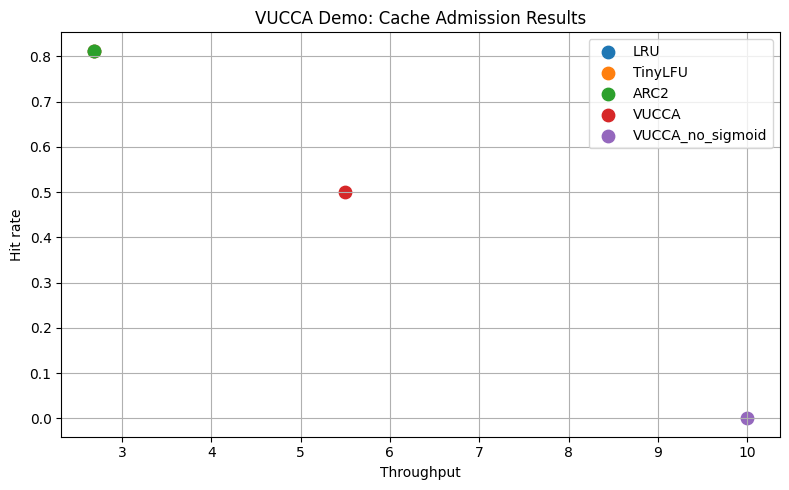

In [16]:
import pandas as pd

rows = []
for regime_data in all_results:
    for r in regime_data["results"]:
        rows.append({
            "regime": regime_data["regime"],
            "method": r["method"],
            "hit_rate": r["hit_rate"],
            "throughput": r["throughput"],
            "coverage": r.get("coverage", 0.0),
        })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
for method in df["method"].unique():
    sub = df[df["method"] == method]
    ax.scatter(sub["throughput"], sub["hit_rate"], label=method, s=80)
ax.set_xlabel("Throughput")
ax.set_ylabel("Hit rate")
ax.set_title("VUCCA Demo: Cache Admission Results")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()